In [49]:
print("hello world")

hello world


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Import Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load Data
df = pd.read_csv("train_BRCpofr.csv")
df.drop(columns=['id'], inplace=True, errors='ignore')


In [51]:
df.head()   

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


In [55]:
# 1. Определение целевой переменной (Target)
# Создаем 3 категории: Low, Medium, High на основе cltv
df['cltv_class'] = pd.qcut(df['cltv'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Балансировка данных (по совету преподавателя)
# Берем по 3500 строк для каждого класса (3000 на обучение + 500 на тест)
df_balanced = df.groupby('cltv_class', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 3500), random_state=42)
).reset_index(drop=True)

# Check the distribution of our new target
print(df['cltv_class'].value_counts())

cltv_class
Low       29802
Medium    29795
High      29795
Name: count, dtype: int64


In [57]:
# 3. Подготовка признаков (X) и цели (y)
# Удаляем таргеты и id, чтобы избежать утечки данных (Data Leakage)
target_col = 'cltv_class'
X_balanced = df_balanced.drop(columns=[target_col], errors='ignore')
y_balanced = df_balanced[target_col]

# Автоматически определяем числовые и категориальные признаки
num_cols = X_balanced.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_balanced.select_dtypes(include=['object']).columns

# 4. Создание препроцессора
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 5. Разделение на Train/Test (по 500 строк на класс в тесте)
# 1500 строк для теста от общего количества (10500)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=1500, 
    random_state=42, 
    stratify=y_balanced
)


print(f"Обучение: {X_train.shape[0]} строк") # Должно быть 9000
print(f"Тест: {X_test.shape[0]} строк")      # Должно быть 1500

KeyError: 'cltv_class'

In [ ]:
# 4. Train Classification Models

# Model 1: Logistic Regression
log_reg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=900, random_state=42))
])
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

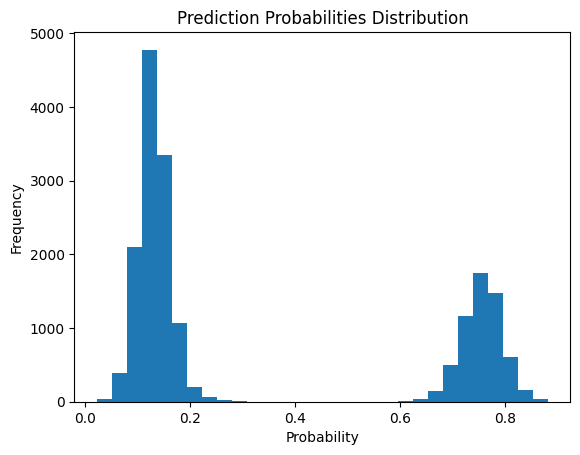

In [ ]:
y_probs = log_reg_pipeline.predict_proba(X_test)[:, 1]

plt.hist(y_probs, bins=30)
plt.title("Prediction Probabilities Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Model 2: K-Nearest Neighbors
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=3))
])
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [ ]:
# Model 3: Decision Tree
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=8))
])
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [ ]:
# 5. Make Predictions & 6. Evaluation

models = {
    "Logistic Regression": log_reg_pipeline,
    "K-Nearest Neighbors": knn_pipeline,
    "Decision Tree": dt_pipeline
}

evaluation_results = {}

 Evaluatiing Logistic Regression 
Accuracy: 0.5913

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.71      0.60      5959
         Low       0.75      0.74      0.75      5961
      Medium       0.49      0.33      0.39      5959

    accuracy                           0.59     17879
   macro avg       0.59      0.59      0.58     17879
weighted avg       0.59      0.59      0.58     17879



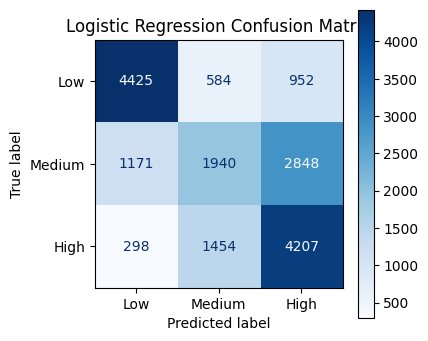



 Evaluatiing K-Nearest Neighbors 
Accuracy: 0.5207

Classification Report:
              precision    recall  f1-score   support

        High       0.47      0.59      0.53      5959
         Low       0.69      0.65      0.67      5961
      Medium       0.40      0.32      0.36      5959

    accuracy                           0.52     17879
   macro avg       0.52      0.52      0.52     17879
weighted avg       0.52      0.52      0.52     17879



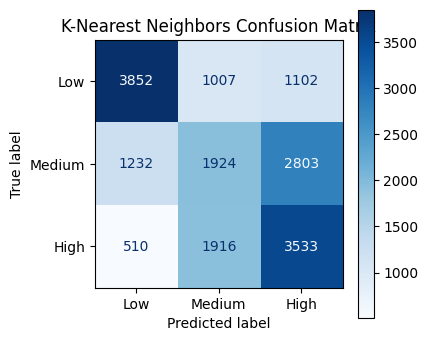



 Evaluatiing Decision Tree 
Accuracy: 0.5907

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.68      0.60      5959
         Low       0.75      0.74      0.74      5961
      Medium       0.48      0.35      0.41      5959

    accuracy                           0.59     17879
   macro avg       0.59      0.59      0.58     17879
weighted avg       0.59      0.59      0.58     17879



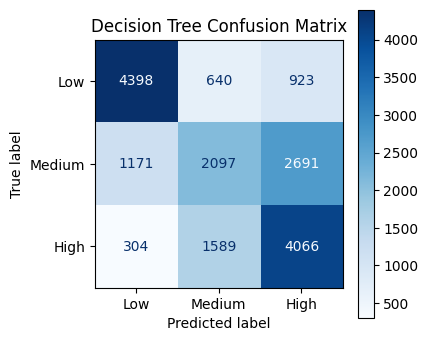

In [ ]:
for model_name, pipeline in models.items():
    print(f" Evaluatiing {model_name} ")
    
    # Generate predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    evaluation_results[model_name] = acc
    
    print(f"Accuracy: {acc:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
    
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()
    print("\n" + "="*50 + "\n")

In [ ]:
# 7. Model Comparison

# Convert results dictionary to a DataFrame for easy viewing
comparison_df = pd.DataFrame(list(evaluation_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

print(" Model Comparison Summary")
print(comparison_df.to_string(index=False))

best_model = comparison_df.iloc[0]['Model']
print(f"\nBest Performing Model: {best_model}")

 Model Comparison Summary
              Model  Accuracy
Logistic Regression  0.591308
      Decision Tree  0.590693
K-Nearest Neighbors  0.520667

Best Performing Model: Logistic Regression
